In [1]:
%matplotlib inline
from __future__ import division
import matplotlib
import numpy as np
from pylab import *
import os
matplotlib.rcParams.update({"axes.formatter.limits": (-4,4)})
plotStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0}
stepStyles={"markersize":20,"markeredgewidth":3.0,"linewidth":3.0,"where":"post"}
np.seterr(divide='ignore',invalid='ignore')
pass

### Setup the notebook.

In [2]:
import h5py
import math
testNames=["first_order_birth_death_time_limit",
           "first_order_birth_death_lower_species_limit",
           "first_order_birth_death_upper_species_limit",
           "first_order_birth_death_fpt_tracking"]
test_names_bash_list=" ".join(testNames)
def isclose(a, b, rel_tol=1e-09, abs_tol=0.0):
    return abs(a-b) <= max(rel_tol * max(abs(a), abs(b)), abs_tol)

In [3]:
%%bash
rm -rf tmp && mkdir tmp

### Execute the simulations.

In [4]:
%%bash -s "$test_names_bash_list"
sbmlFilename="first_order_birth_death.sbml"
for testName in $1; do
    outputFilename=tmp/${testName}.lm
    rm -f ${outputFilename}* && lm_sbml_import ${outputFilename} ${sbmlFilename} > ${outputFilename}.import.log
    if [ ${testName} == "first_order_birth_death_time_limit" ]; then
        lm_setp ${outputFilename} writeInterval=1e-2 maxTime=1e1 > /dev/null
    elif [ ${testName} == "first_order_birth_death_no_limit" ]; then
        lm_setp ${outputFilename} writeInterval=1e-2 > /dev/null
    elif [ ${testName} == "first_order_birth_death_lower_species_limit" ]; then
        lm_setp ${outputFilename} writeInterval=1e-2 maxTime=1e2 "speciesLowerLimitList=0:900" > /dev/null
    elif [ ${testName} == "first_order_birth_death_upper_species_limit" ]; then
        lm_setp ${outputFilename} writeInterval=1e-2 maxTime=1e2 "speciesUpperLimitList=0:2002" > /dev/null
    elif [ ${testName} == "first_order_birth_death_fpt_tracking" ]; then
        lm_setp ${outputFilename} writeInterval=1e-2 maxTime=1e2 fptTrackingList=0 > /dev/null
    else
        echo "Invalid test name: ${testName}"
        continue
    fi
    lmes -r 1-1000 -f ${outputFilename} > ${outputFilename}.simulate.log
done;
echo "Finished."

Finished.


### Spot check some simulations.

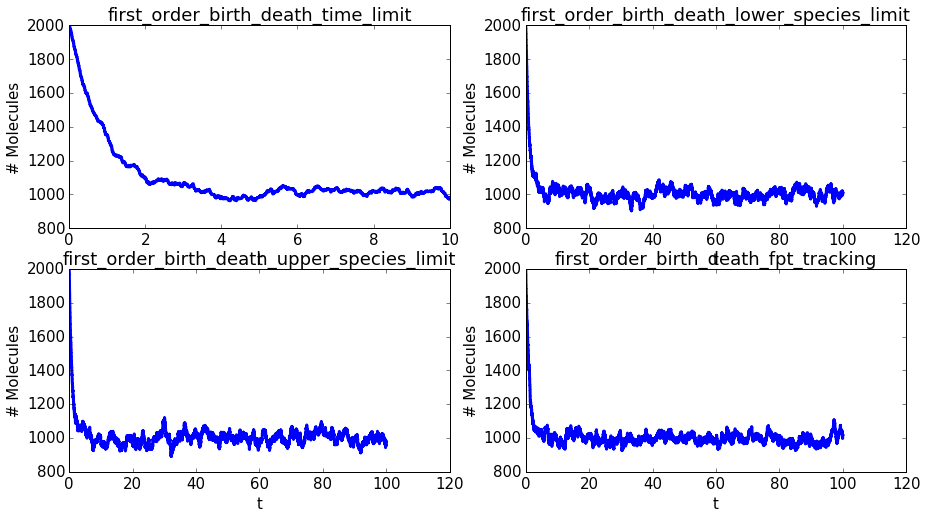

In [5]:
# Plot the time series for a single replicate.
for i,testName in enumerate(testNames):
    testOutputFilename="tmp/%s.lm"%(testName)
    fp = h5py.File(testOutputFilename, "r")
    cols=2
    rows=len(testNames)/cols
    matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (15,4*rows)})
    for replicate in (1,):
        counts=np.array(fp["/Simulations/%07d/SpeciesCounts"%replicate], dtype=double)
        times=np.array(fp["/Simulations/%07d/SpeciesCountTimes"%replicate], dtype=double)
        plt.subplot(rows,cols,i+1)
        step(times,counts[:,0], **stepStyles)
        xlabel('t'); ylabel('# Molecules'); title("%s"%(testName))
    fp.close()
pass

### Define the tests.

In [6]:
def test_first_order_birth_death_time_limit(testOutputFilename):
    fp = h5py.File(testOutputFilename, "r")
    replicates=fp["/Simulations"].keys()
    k=0
    mSim=None
    vSim=None
    times=None
    for replicate in replicates:
        if times is None:
            times = np.array(fp["/Simulations/%s/SpeciesCountTimes"%replicate], dtype=double)
        counts = np.array(fp["/Simulations/%s/SpeciesCounts"%replicate], dtype=double)
        if mSim is None:
            k += 1
            mSim = counts
            vSim = np.zeros(counts.shape, dtype=double)
        else:
            k += 1
            mSim = mSim + (counts-mSim)/k
            vSim = vSim + (counts-mSim)*(counts-mSim)
    vSim /= float((k-1))

    # Plot the accuracy of the mean and variance.
    matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (15,3)})
    ax=plt.subplot(1,2,1)
    plt.plot(times,mSim, **plotStyles)
    ax.set_yscale('log'); xlabel('t'); ylabel('E{X(t)}'); title("%s"%(testOutputFilename))
    ax=plt.subplot(1,2,2)
    plt.plot(times,vSim, **plotStyles)
    ax.set_yscale('log'); xlabel('t'); ylabel('Var{X(t)}'); title("%s"%(testOutputFilename))
    fp.close()

    value = np.mean(mSim[len(mSim)//2:])
    if not isclose(value,1000.0,1e-2): raise Exception("incorrect value for mean",value)
    value = np.mean(vSim[len(mSim)//2:])
    if not isclose(value,1020.0,5e-2): raise Exception("incorrect value for variance",value)

In [7]:
def test_first_order_birth_death_lower_species_limit(testOutputFilename):
    fp = h5py.File(testOutputFilename, "r")
    replicates=fp["/Simulations"].keys()
    finalTimes=[]
    finalCounts=[]
    for replicate in replicates:
        counts = fp["/Simulations/%s/SpeciesCounts"%replicate]
        times = fp["/Simulations/%s/SpeciesCountTimes"%replicate]
        finalTimes.append(times[-1])
        finalCounts.append(counts[-1])
            
    # Plot the final times.
    matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (15,3)})
    subplot(1,2,1)
    hist(finalTimes,100)
    xlabel('Final Time'); ylabel('# Runs'); title("%s"%(testOutputFilename))
    fp.close()
    
    value = np.min(finalCounts)
    if value != 900: raise Exception("incorrect value for final count",value)

In [8]:
def test_first_order_birth_death_upper_species_limit(testOutputFilename):
    fp = h5py.File(testOutputFilename, "r")
    replicates=fp["/Simulations"].keys()
    finalTimes=[]
    finalCounts=[]
    for replicate in replicates:
        counts = fp["/Simulations/%s/SpeciesCounts"%replicate]
        times = fp["/Simulations/%s/SpeciesCountTimes"%replicate]
        finalTimes.append(times[-1])
        finalCounts.append(counts[-1])
            
    # Plot the final times.
    matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (15,3)})
    subplot(1,2,1)
    hist(finalTimes,100)
    xlabel('Final Time'); ylabel('# Runs'); title("%s"%(testOutputFilename))
    fp.close()
    
    value = np.max(finalCounts)
    if value != 2002: raise Exception("incorrect value for final count",value)

In [9]:
def test_first_order_birth_death_fpt_tracking(testOutputFilename):
    fp = h5py.File(testOutputFilename, "r")
    replicates=fp["/Simulations"].keys()    
    allCounts = np.zeros((2100,), dtype=double)
    allTimes = np.zeros((2100,), dtype=double)
    for replicate in replicates:
        counts=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Counts"%replicate], dtype=double)
        times=np.array(fp["/Simulations/%s/FirstPassageTimes/00/Times"%replicate], dtype=double)
        start = int(counts[0])
        end = start+counts.shape[0]
        allCounts[start:end] += 1    
        allTimes[start:end] += times
    allTimes /= allCounts

    # Plot the mean first passage times.
    matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (15,3)})
    subplot(1,2,1)
    plot(np.arange(0,len(allCounts), dtype=double),allTimes, **plotStyles)
    yscale('log'); xlabel('X'); ylabel('E{FPT(X)}'); title("%s"%(testOutputFilename))
    
    value = allTimes[1000]    
    if not isclose(value,4.1,1e-1): raise Exception("incorrect value for mfpt[0]",value)

### Run the tests.

[first_order_birth_death_time_limit]                         : passed.


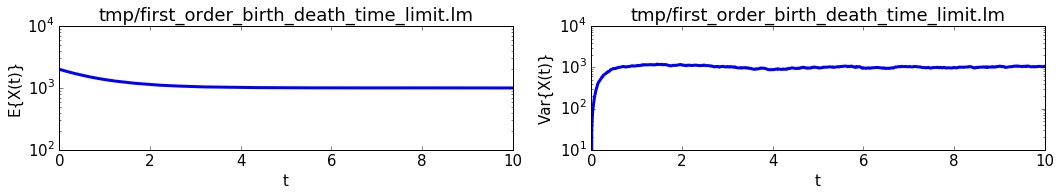

[first_order_birth_death_lower_species_limit]                : passed.


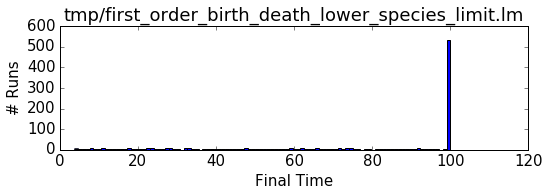

[first_order_birth_death_upper_species_limit]                : passed.


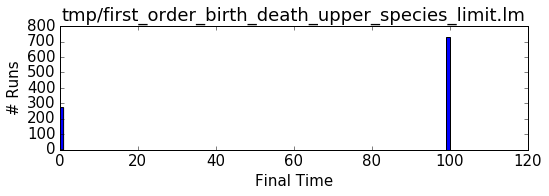

[first_order_birth_death_fpt_tracking]                       : passed.


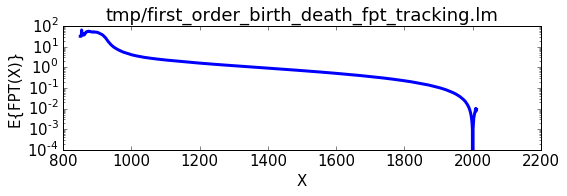

In [10]:
testMethods = {"first_order_birth_death_time_limit": test_first_order_birth_death_time_limit,
               "first_order_birth_death_lower_species_limit": test_first_order_birth_death_lower_species_limit,
               "first_order_birth_death_upper_species_limit": test_first_order_birth_death_upper_species_limit,
               "first_order_birth_death_fpt_tracking": test_first_order_birth_death_fpt_tracking}
matplotlib.rcParams.update({'font.size': 15, "figure.figsize": (20,5*len(testNames))})
i=1
for testName in testNames:
    try:
        testOutputFilename="tmp/%s.lm"%(testName)
        testMethods[testName](testOutputFilename)
    except Exception as e:
        print "%-60s : FAILED with:"%("["+testName+"]"),e
    except:
        print "%-60s : FAILED with: Unknown exception"%("["+testName+"]")
    else:
        print "%-60s : passed."%("["+testName+"]")
    plt.tight_layout()
    plt.show()
pass

In [11]:
%%bash
rm -rf tmp